# Brooklyn Community District Case Study

This notebook loads a packaged Brooklyn sample into memory and uses it for exploratory analysis with notebook-native tables and simple charts.

Setup for local use:
- run `uv sync --extra science --group notebooks`
- select the project `.venv` / `nyc311` kernel in Jupyter or VS Code

The flow is deliberately path-free so someone can open it in Colab or a fresh notebook environment and start working immediately.

In [1]:
from collections import Counter
from datetime import date

from IPython.display import display

import nyc311

records = nyc311.load_sample_service_requests(
    filters=nyc311.ServiceRequestFilter(
        start_date=date(2025, 1, 1),
        end_date=date(2025, 3, 31),
        geography=nyc311.GeographyFilter(geography="borough", value="BROOKLYN"),
    )
)

len(records)

8

,complaint_type,count
0,Noise - Residential,4
1,Rodent,2
2,Illegal Parking,1
3,Blocked Driveway,1


,community_district,count
0,BROOKLYN 01,5
1,BROOKLYN 03,3


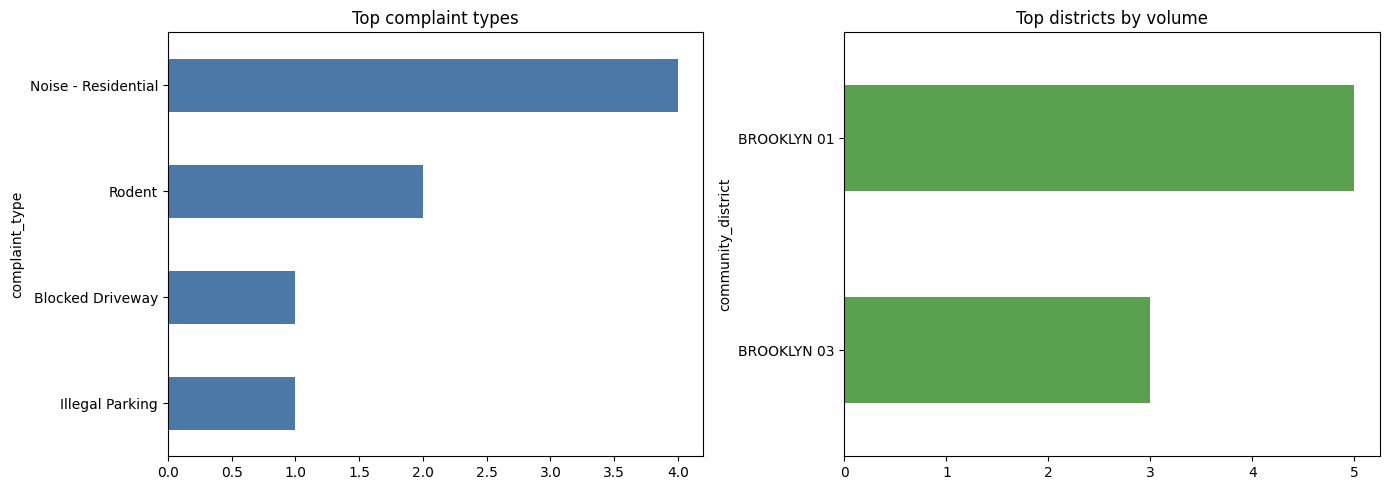

In [2]:
complaint_type_counts = Counter(record.complaint_type for record in records)
district_counts = Counter(record.community_district for record in records)

complaint_type_df = nyc311.records_to_dataframe(records)[["complaint_type"]]
complaint_type_df = (
    complaint_type_df["complaint_type"]
    .value_counts()
    .rename_axis("complaint_type")
    .reset_index(name="count")
)
district_df = (
    nyc311.records_to_dataframe(records)["community_district"]
    .value_counts()
    .rename_axis("community_district")
    .reset_index(name="count")
)

display(complaint_type_df.head(10))
display(district_df.head(10))

try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
    complaint_type_df.head(10).sort_values("count").plot.barh(
        x="complaint_type",
        y="count",
        ax=axes[0],
        color="#4C78A8",
        legend=False,
        title="Top complaint types",
    )
    district_df.head(10).sort_values("count").plot.barh(
        x="community_district",
        y="count",
        ax=axes[1],
        color="#59A14F",
        legend=False,
        title="Top districts by volume",
    )
    plt.tight_layout()
    plt.show()
except ImportError:
    complaint_type_counts.most_common(10), district_counts.most_common(10)

,geography,geography_value,complaint_type,total_request_count,resolved_request_count,unresolved_request_count,unresolved_share,resolution_rate
0,borough,BROOKLYN,Noise - Residential,4,4,0,0.0,1.0
1,borough,BROOKLYN,Rodent,2,2,0,0.0,1.0
2,borough,BROOKLYN,Blocked Driveway,1,1,0,0.0,1.0
3,borough,BROOKLYN,Illegal Parking,1,1,0,0.0,1.0


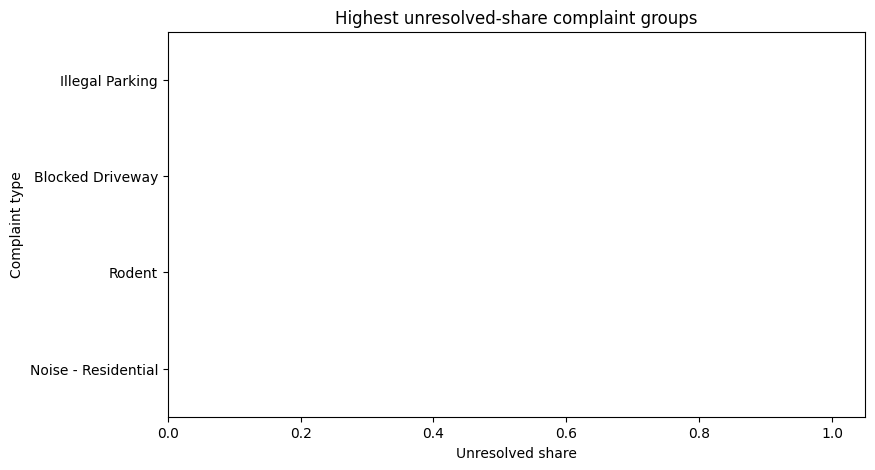

In [3]:
resolution_records = [
    record for record in records if record.resolution_description is not None
]
resolution_summaries = nyc311.analyze_resolution_gaps(records, resolution_records)
resolution_df = nyc311.gaps_to_dataframe(resolution_summaries)
display(resolution_df.head(10))

try:
    import matplotlib.pyplot as plt

    plot_df = resolution_df.head(10).sort_values("unresolved_share")
    ax = plot_df.plot.barh(
        x="complaint_type",
        y="unresolved_share",
        figsize=(9, 5),
        color="#E15759",
        legend=False,
        title="Highest unresolved-share complaint groups",
    )
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Unresolved share")
    ax.set_ylabel("Complaint type")
    plt.show()
except ImportError:
    display(resolution_df[["complaint_type", "unresolved_share"]].head(10))

,geography,geography_value,complaint_type,topic,complaint_count,geography_total_count,share_of_geography,topic_rank,is_dominant_topic
0,community_district,BROOKLYN 01,Noise - Residential,banging,1,2,0.5,1,True
2,community_district,BROOKLYN 03,Noise - Residential,construction,1,2,0.5,1,True


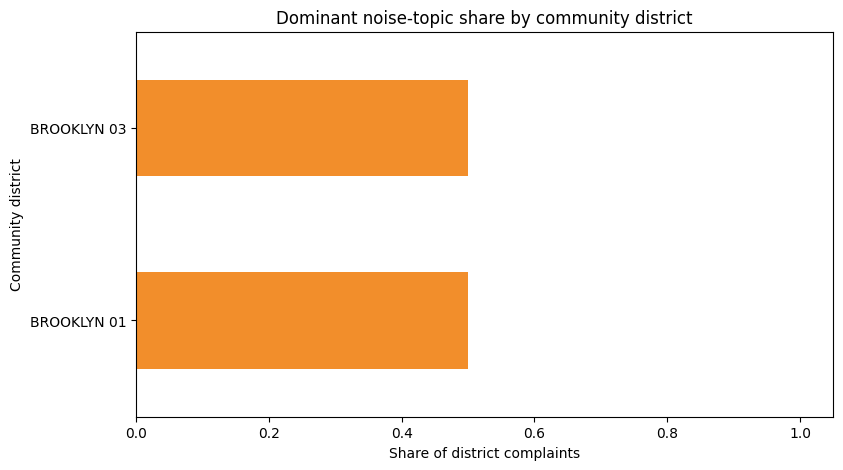

In [4]:
noise_records = [
    record for record in records if record.complaint_type == "Noise - Residential"
]
assignments = nyc311.extract_topics(
    noise_records,
    nyc311.TopicQuery("Noise - Residential"),
)
summaries = nyc311.aggregate_by_geography(assignments, geography="community_district")
summaries_df = nyc311.summaries_to_dataframe(summaries)
dominant_noise_df = summaries_df[summaries_df["is_dominant_topic"]].sort_values(
    "share_of_geography",
    ascending=False,
)

display(dominant_noise_df.head(10))

try:
    import matplotlib.pyplot as plt

    ax = (
        dominant_noise_df.head(12)
        .sort_values("share_of_geography")
        .plot.barh(
            x="geography_value",
            y="share_of_geography",
            figsize=(9, 5),
            color="#F28E2B",
            legend=False,
            title="Dominant noise-topic share by community district",
        )
    )
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Share of district complaints")
    ax.set_ylabel("Community district")
    plt.show()
except ImportError:
    display(
        dominant_noise_df[["geography_value", "topic", "share_of_geography"]].head(10)
    )

In [5]:
# Optional: export later if you decide this live slice is worth keeping.
# The notebook itself stays notebook-native and avoids active file writes.
#
# For repeatable bulk downloads or script-driven workflows, see
# examples/scripts/.
#
# nyc311.export_service_requests_csv(
#     records,
#     nyc311.ExportTarget("csv", "brooklyn-large-sample.csv"),
# )
#
# nyc311.export_topic_table(
#     summaries,
#     nyc311.ExportTarget("csv", "brooklyn-noise-community-districts.csv"),
# )